# CAMM Hackathon 15: Vector Field Problem - NanoLithography


- In scanning-probe nanolithography, a biased AFM tip can switch ferroelectric polarization not only through voltage amplitude, but also through the geometry of its motion.
- The tip trajectory creates an effective in-plane electric-field pattern that can guide local switching and stabilize designed domain configurations.

Examples:

[Vasudevan, R.; et al. On-demand nanoengineering of in-plane ferroelectric topologies](https://www.nature.com/articles/s41565-024-01792-1)

[Vasudevan R., et al. Deterministic arbitrary switching of polarization in a ferroelectric thin film](https://www.nature.com/articles/ncomms5971)

####Today, we are going to focus on **designing lithography trajectories** that generate target electric-field patterns in a minimal ferroelectric model.



We consider a sharp, electrically biased probe moving across a ferroelectric surface. As the probe moves, it can locally switch the material’s polarization, making the lithography trajectory itself part of the design problem.

Two key assumptions define the simplified model:

- A moving probe creates an effective trailing in-plane field in its wake. The local polarization tends to align with the direction of probe motion.
- At each moment, you control two main parameters: the probe position or path, and the applied voltage (V). In a more complete model, the probe speed could also be included, since it affects domain-growth dynamics and therefore the final written pattern.

In this simplified challenge, the effective writing field is approximated as


$\;\mathbf{E}_{\text{eff}} = V\cdot\hat{\mathbf t}\;$

where ($\hat{\mathbf t}$) is the local travel direction of the probe. The direction of motion sets the field orientation, the voltage sets its sign and strength, and larger ($|V|$) switches a wider region of the material.

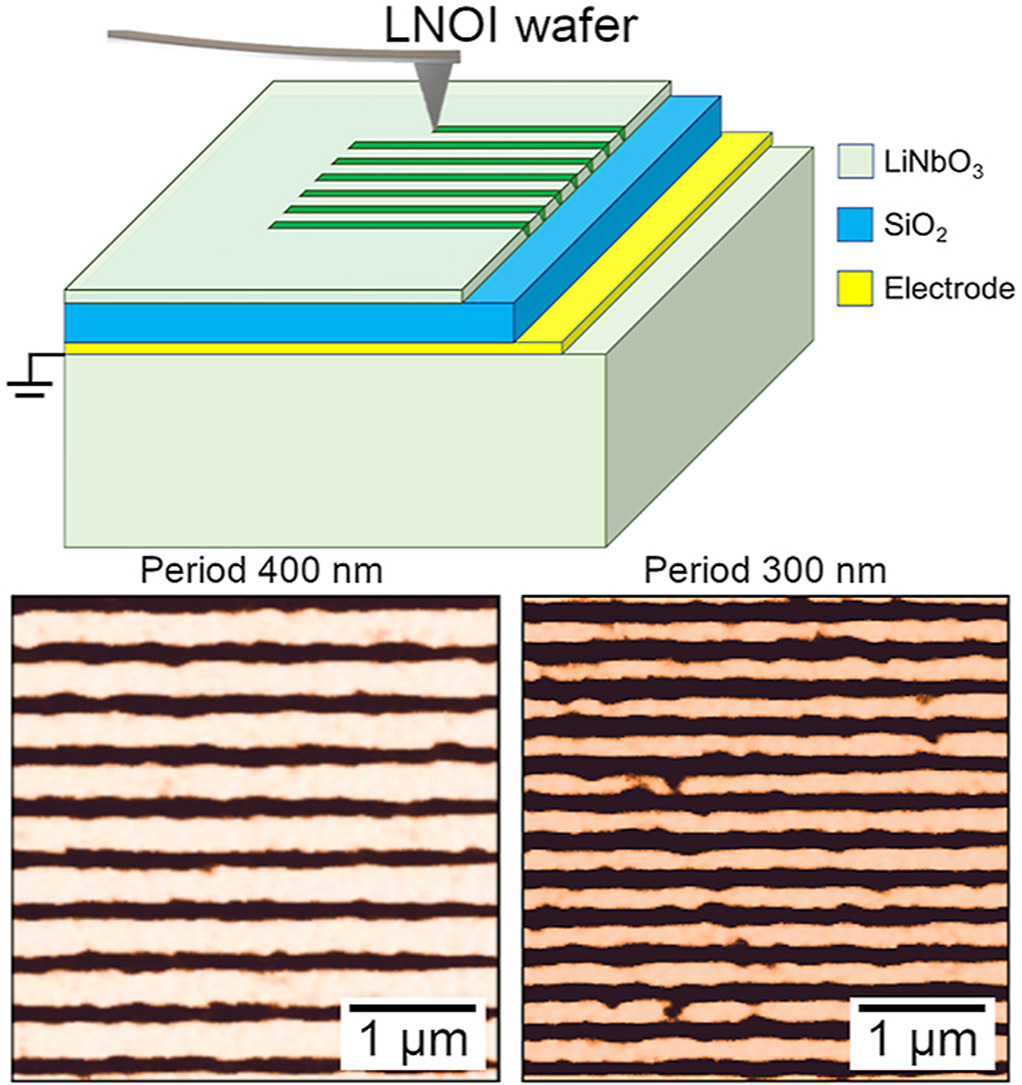

*https://www.sciencedirect.com/science/article/pii/S0272884221025785

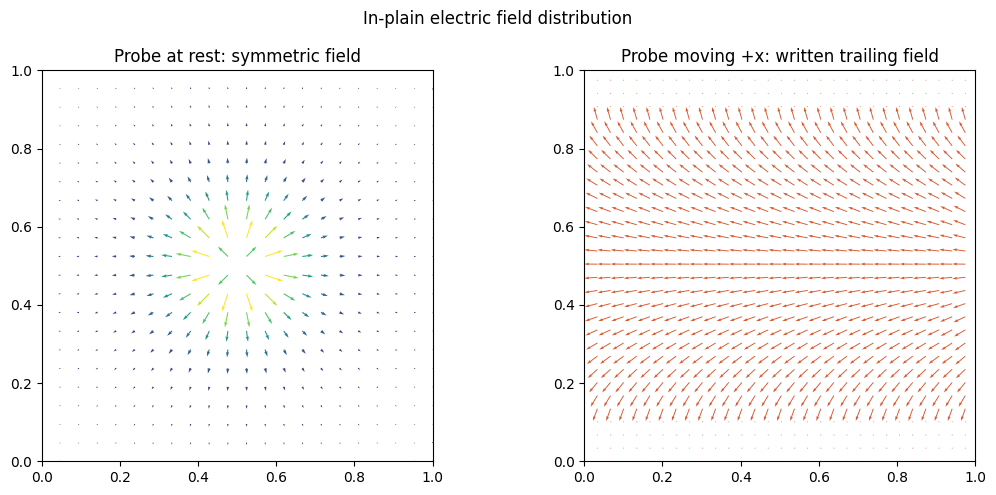

In [1]:
import numpy as np, matplotlib.pyplot as plt

h = 0.10                                   # pen (point-charge) height above the surface
def E(X, Y, xc, yc):                       # in-plane surface field from a charge at (xc, yc, h)
    dx, dy = X - xc, Y - yc
    r3 = (dx*dx + dy*dy + h*h)**1.5
    return dx/r3, dy/r3

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# --- AT REST: charge sits at the centre -> symmetric field, no chosen direction ---
g = np.linspace(0, 1, 22); X, Y = np.meshgrid(g, g)
Ex, Ey = E(X, Y, 0.5, 0.5)
ax[0].quiver(X, Y, Ex, Ey, np.hypot(Ex, Ey), cmap="viridis", scale=800)
ax[0].set_title("Probe at rest: symmetric field")

# --- MOVING +x: the spot that switches LAST is written (overwrite) -> a trailing wake ---
gg = np.linspace(0, 1, 120); Xs, Ys = np.meshgrid(gg, gg)
Px = np.zeros_like(Xs); Py = np.zeros_like(Xs); Ec = 6.0     # switching threshold
for xc in np.linspace(-0.25, 1.25, 300):                     # pen sweeps left -> right
    ex, ey = E(Xs, Ys, xc, 0.5); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]              # last write wins
s = slice(None, None, 4)
ax[1].quiver(Xs[s, s], Ys[s, s], Px[s, s], Py[s, s], color="#D85A30", scale=30)
ax[1].set_title("Probe moving +x: written trailing field")

for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.suptitle('In-plain electric field distribution')
plt.tight_layout(); plt.show()

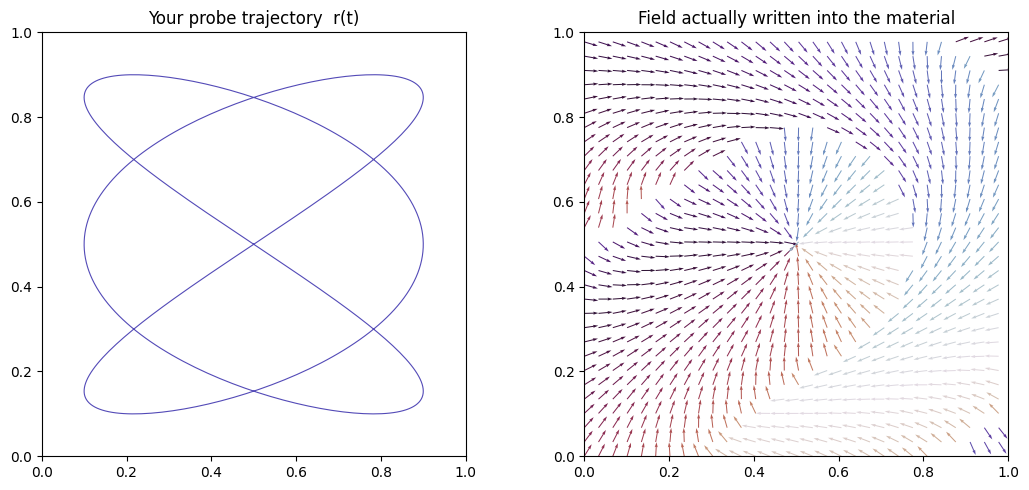

In [2]:
import numpy as np, matplotlib.pyplot as plt

h, Ec = 0.06, 12.0                         # pen height above surface, switching threshold
def Efield(X, Y, xc, yc, V):               # in-plane field of the charged pen (V scales it)
    dx, dy = X - xc, Y - yc; r3 = (dx*dx + dy*dy + h*h)**1.5
    return V*dx/r3, V*dy/r3

# ---- YOUR design: path r(t) + voltage V(t)  (sign of V = direction, |V| = brush width) ----
t = np.linspace(0, 1, 500)
def path(t): return 0.5 + 0.40*np.sin(2*np.pi*3*t), 0.5 + 0.40*np.sin(2*np.pi*2*t)
def volt(t): return np.where(t < 0.5, 1.0, -1.0)        # e.g. flip the sign halfway
xc, yc = path(t); V = volt(t)

# ---- write into the film: move the pen; the last above-threshold field wins (overwrite) ----
g = np.linspace(0, 1, 90); X, Y = np.meshgrid(g, g)
Px = np.full_like(X, np.nan); Py = np.full_like(X, np.nan)
for i in range(len(t)):
    ex, ey = Efield(X, Y, xc[i], yc[i], V[i]); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].plot(xc, yc, lw=.8, c="#534AB7"); ax[0].set_title("Your probe trajectory  r(t)")
s = slice(None, None, 3)
ax[1].quiver(X[s,s], Y[s,s], Px[s,s], Py[s,s], np.arctan2(Py, Px)[s,s],
             cmap="twilight", scale=30)
ax[1].set_title("Field actually written into the material")
for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### Possible Problems to be Solves


#### **1. Prompt-to-trajectory generation**

Develop a system that converts a user request into a lithography trajectory.
For example, given prompts such as “write a vortex,” “create a centre-divergent pattern,” or “make a dense array of flux-closure-like structures,” the system should generate a probe path (x(t), y(t)) and voltage profile (V(t)).

#### 2. **Forward simulation of the written pattern (high complexity)**

Build a simplified model that predicts the resulting in-plane polarization or electric-field pattern from a proposed trajectory.
The model does not need to describe the full probe–sample physics, but should capture the main idea: probe motion defines the local field direction, voltage defines switching strength and sign, and material response can be approximated through simple parameters such as permittivity or switching width.

#### 3. **Trajectory optimization**

Given a target structure type and constraints, optimize the trajectory parameters.
Possible objectives include improving pattern quality, increasing feature density, reducing writing time, minimizing voltage exposure, or matching a desired domain size.

#### 4. **Inverse design from a target pattern**

Solve the inverse problem: given a desired vector-field image/pattern, generate a trajectory that could approximately write it.


The solution can be implemented either as an agentic system or as any other algorithmic approach.

In [3]:
len(xc)

500

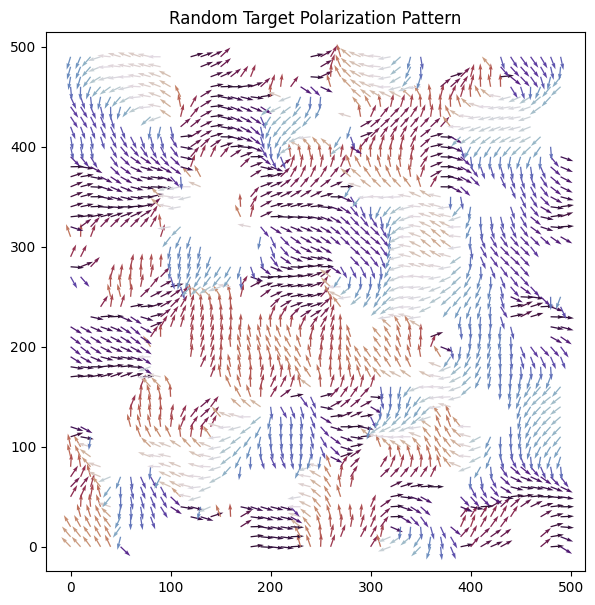

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ---------------------------
# generate random domain map
# ---------------------------

N = 500

# create smooth random fields
rx = gaussian_filter(np.random.randn(N, N), sigma=20)
ry = gaussian_filter(np.random.randn(N, N), sigma=20)

# normalize to unit vectors
mag = np.sqrt(rx**2 + ry**2)

target_Px = rx / mag
target_Py = ry / mag

# optional: introduce unswitched regions
mask = gaussian_filter(np.random.rand(N, N), sigma=15)
inactive = mask < np.percentile(mask, 20)

target_Px[inactive] = np.nan
target_Py[inactive] = np.nan

# ---------------------------
# visualize target
# ---------------------------

step = 10

plt.figure(figsize=(7,7))

plt.quiver(
    np.arange(0, N, step),
    np.arange(0, N, step),
    target_Px[::step, ::step],
    target_Py[::step, ::step],
    np.arctan2(
        target_Py[::step, ::step],
        target_Px[::step, ::step]
    ),
    cmap="twilight",
    scale=40
)

plt.gca().set_aspect("equal")
plt.title("Random Target Polarization Pattern")
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cma

In [6]:
# Grid (use 100 for optimization speed; switch to 500 for final eval)
N = 120

g = np.linspace(0, 1, N)
X, Y = np.meshgrid(g, g)

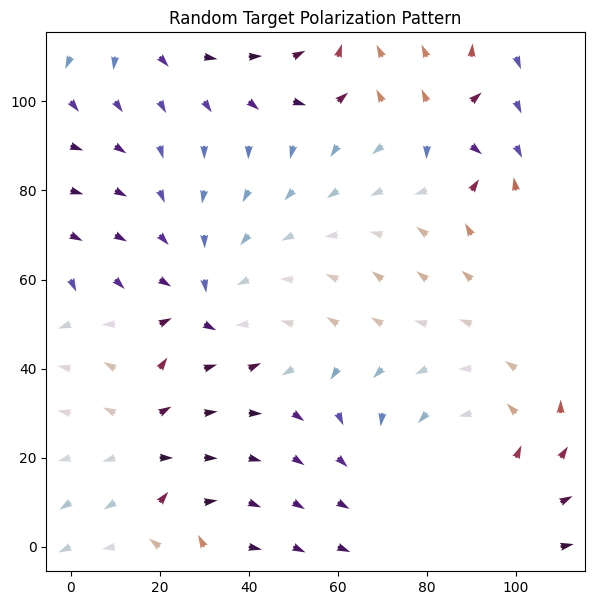

In [7]:
from scipy.ndimage import gaussian_filter

def make_target(N=120, sigma=12):

    rx = gaussian_filter(np.random.randn(N, N), sigma=sigma)
    ry = gaussian_filter(np.random.randn(N, N), sigma=sigma)

    mag = np.sqrt(rx**2 + ry**2) + 1e-12

    Px = rx / mag
    Py = ry / mag

    # mask (optional unswitched regions)
    mask = gaussian_filter(np.random.rand(N, N), sigma=sigma)
    inactive = mask < np.percentile(mask, 15)

    Px[inactive] = np.nan
    Py[inactive] = np.nan

    return Px, Py


target_Px, target_Py = make_target(N)


# ---------------------------
# visualize target
# ---------------------------

step = 10

plt.figure(figsize=(7,7))

plt.quiver(
    np.arange(0, N, step),
    np.arange(0, N, step),
    target_Px[::step, ::step],
    target_Py[::step, ::step],
    np.arctan2(
        target_Py[::step, ::step],
        target_Px[::step, ::step]
    ),
    cmap="twilight",
    scale=40
)

plt.gca().set_aspect("equal")
plt.title("Random Target Polarization Pattern")
plt.show()



# 📈 3. Trajectory parameterization (spline)

In [8]:
from scipy.interpolate import CubicSpline

class Trajectory:

    def __init__(self, n_ctrl=8, n_steps=200):
        self.n_ctrl = n_ctrl
        self.n_steps = n_steps

    def generate(self, cx, cy, cv):

        t_ctrl = np.linspace(0, 1, self.n_ctrl)
        t = np.linspace(0, 1, self.n_steps)

        sx = CubicSpline(t_ctrl, cx)
        sy = CubicSpline(t_ctrl, cy)
        sv = CubicSpline(t_ctrl, cv)

        xc = np.clip(sx(t), 0, 1)
        yc = np.clip(sy(t), 0, 1)
        V  = np.clip(sv(t), -2, 2)

        return xc, yc, V

    def path_length(self, xc, yc):
        return np.sum(np.sqrt(np.diff(xc)**2 + np.diff(yc)**2))

# ⚡ 4. Vectorized AFM simulator (FAST CORE)

In [9]:
class VectorizedAFM:

    def __init__(self, X, Y, h=0.06, Ec=12.0):
        self.X = X
        self.Y = Y
        self.h = h
        self.Ec = Ec
        self.eps = 1e-12

    def simulate(self, xc, yc, V):

        T = len(xc)

        dx = self.X[None,:,:] - xc[:,None,None]
        dy = self.Y[None,:,:] - yc[:,None,None]

        r2 = dx*dx + dy*dy + self.h*self.h
        inv_r3 = 1.0 / (r2 * np.sqrt(r2) + self.eps)

        Ex = V[:,None,None] * dx * inv_r3
        Ey = V[:,None,None] * dy * inv_r3

        mag = np.sqrt(Ex**2 + Ey**2)

        sw = mag > self.Ec

        Exn = np.zeros_like(Ex)
        Eyn = np.zeros_like(Ey)

        Exn[sw] = Ex[sw] / (mag[sw] + self.eps)
        Eyn[sw] = Ey[sw] / (mag[sw] + self.eps)

        # last write wins
        idx = np.arange(T)[:,None,None]
        last = np.max(np.where(sw, idx, -1), axis=0)

        Px = np.zeros_like(self.X)
        Py = np.zeros_like(self.Y)

        valid = last >= 0

        Px[valid] = Exn[last[valid],
                        np.broadcast_to(np.arange(self.X.shape[0])[:,None], self.X.shape)[valid],
                        np.broadcast_to(np.arange(self.X.shape[1])[None,:], self.X.shape)[valid]]

        Py[valid] = Eyn[last[valid],
                        np.broadcast_to(np.arange(self.X.shape[0])[:,None], self.X.shape)[valid],
                        np.broadcast_to(np.arange(self.X.shape[1])[None,:], self.X.shape)[valid]]

        return Px, Py

# 🎯 5. Objective function

In [10]:
class Objective:

    def __init__(self, path_weight=0.02):
        self.path_weight = path_weight

    def similarity(self, Tx, Ty, Px, Py):

        valid = ~np.isnan(Tx)

        dot = Tx[valid]*Px[valid] + Ty[valid]*Py[valid]

        return np.mean(dot)

    def loss(self, Tx, Ty, Px, Py, path_len):

        sim = self.similarity(Tx, Ty, Px, Py)

        loss = (
            (1 - sim)
            + self.path_weight * path_len
        )

        return loss, sim

# 🧬 6. Trajectory generator

In [11]:
traj = Trajectory(n_ctrl=8, n_steps=200)
sim  = VectorizedAFM(X, Y)
obj  = Objective()

# 🧠 7. CMA-ES optimizer

In [12]:
class CMAOptimizer:

    def __init__(self, traj, sim, obj, n_ctrl=8):

        self.traj = traj
        self.sim = sim
        self.obj = obj
        self.n_ctrl = n_ctrl
        self.dim = 3*n_ctrl

    def unpack(self, x):

        n = self.n_ctrl

        cx = np.clip(x[:n], 0, 1)
        cy = np.clip(x[n:2*n], 0, 1)
        cv = np.clip(x[2*n:], -2, 2)

        return cx, cy, cv

    def evaluate(self, x, Tx, Ty):

        cx, cy, cv = self.unpack(x)

        xc, yc, V = self.traj.generate(cx, cy, cv)

        Px, Py = self.sim.simulate(xc, yc, V)

        path = self.traj.path_length(xc, yc)

        loss, sim = self.obj.loss(Tx, Ty, Px, Py, path)

        return loss

    def run(self, Tx, Ty, iters=60):

        x0 = np.random.randn(self.dim) * 0.1

        es = cma.CMAEvolutionStrategy(
            x0,
            0.3,
            {'popsize': 16, 'maxiter': iters}
        )

        best = None

        while not es.stop():

            sols = es.ask()
            losses = [self.evaluate(x, Tx, Ty) for x in sols]

            es.tell(sols, losses)

            print("best loss:", min(losses))

        return es.result.xbest

# 🚀 8. Run optimization

In [13]:
opt = CMAOptimizer(traj, sim, obj, n_ctrl=8)

best = opt.run(target_Px, target_Py, iters=40)

(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 24 (seed=185010, Tue Jun  9 11:37:17 2026)
best loss: 0.9399439376506313
best loss: 0.9304165083868857
best loss: 0.9468184727266384
best loss: 0.93227784052485
best loss: 0.9493288886963864
best loss: 0.9750112393703261
best loss: 0.8947392088107466
best loss: 0.958065230944718
best loss: 0.877455938198341
best loss: 0.7650404527802737
best loss: 0.7532596716413598
best loss: 0.871340214614458
best loss: 0.8245976219462585
best loss: 0.8825960504509757
best loss: 0.797923936046135
best loss: 0.7354349145099108
best loss: 0.788346986376756
best loss: 0.6953668785402343
best loss: 0.6795322500282389
best loss: 0.6997042249371274
best loss: 0.7509376914775865
best loss: 0.7266662077365065
best loss: 0.7535537235915393
best loss: 0.7360496382391136
best loss: 0.7342751400099924
best loss: 0.7133066063042249
best loss: 0.7569536975924751
best loss: 0.7200846526690846
best loss: 0.7094240667659605
best loss: 0.7014492672399248
best loss: 0.61

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(X, Y,
                    target_Px, target_Py,
                    recon_Px, recon_Py,
                    step=5):

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ---------------------------
    # TARGET
    # ---------------------------
    ax[0].quiver(
        X[::step, ::step],
        Y[::step, ::step],
        target_Px[::step, ::step],
        target_Py[::step, ::step],
        np.arctan2(
            target_Py[::step, ::step],
            target_Px[::step, ::step]
        ),
        cmap="twilight",
        scale=40
    )

    ax[0].set_title("Target polarization pattern")
    ax[0].set_aspect("equal")
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)

    # ---------------------------
    # RECONSTRUCTED
    # ---------------------------
    ax[1].quiver(
        X[::step, ::step],
        Y[::step, ::step],
        recon_Px[::step, ::step],
        recon_Py[::step, ::step],
        np.arctan2(
            recon_Py[::step, ::step],
            recon_Px[::step, ::step]
        ),
        cmap="twilight",
        scale=40
    )

    ax[1].set_title("Reconstructed pattern (AFM write)")
    ax[1].set_aspect("equal")
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

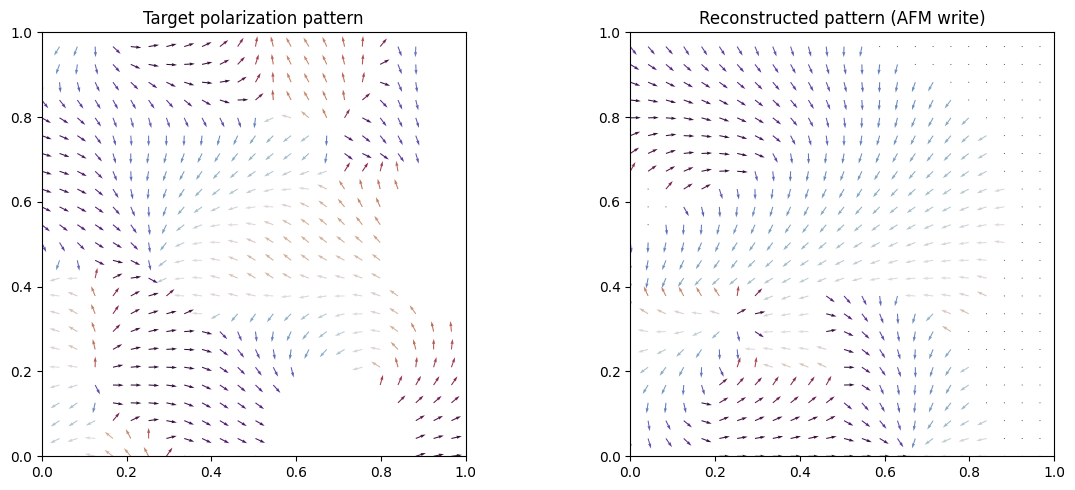

In [15]:
# reconstruct final pattern
cx = best[:8]
cy = best[8:16]
cv = best[16:]

xc, yc, V = traj.generate(cx, cy, cv)

recon_Px, recon_Py = sim.simulate(xc, yc, V)

# compare
plot_comparison(
    X, Y,
    target_Px, target_Py,
    recon_Px, recon_Py,
    step=5
)

# 🔄 9. Decode and visualize result

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_afm_probe(X, Y, xc, yc, h=0.06, step=8):

    fig, ax = plt.subplots(figsize=(6,6))

    # surface grid (light background)
    ax.plot(X, Y, lw=0.3, alpha=0.3)
    ax.plot(X.T, Y.T, lw=0.3, alpha=0.3)

    # full trajectory
    ax.plot(xc, yc, color="purple", lw=2, label="Tip trajectory")

    # current tip position (last point)
    ax.scatter(xc[-1], yc[-1], s=80, color="red", label="Current tip position")

    # show sampled previous positions
    ax.scatter(xc[::step], yc[::step], s=10, color="blue", alpha=0.6)

    # interaction radius (proxy for field spread)
    circle = plt.Circle(
        (xc[-1], yc[-1]),
        radius=h,
        color="red",
        fill=False,
        linestyle="--",
        alpha=0.7,
        label="Interaction radius (h)"
    )

    ax.add_patch(circle)

    ax.set_title("AFM Tip Probe Trajectory on Ferroelectric Surface")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    ax.legend()
    plt.show()

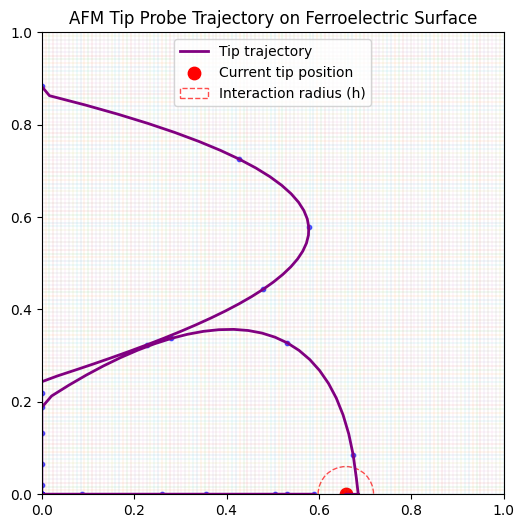

In [17]:
xc, yc, V = traj.generate(cx, cy, cv)

plot_afm_probe(
    X, Y,
    xc, yc,
    h=0.06
)

In [18]:
import numpy as np
import cma
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter

In [19]:
def get_grid(level):

    if level == "coarse":
        N = 80
    elif level == "medium":
        N = 200
    elif level == "fine":
        N = 500
    else:
        raise ValueError("Unknown level")

    g = np.linspace(0, 1, N)
    X, Y = np.meshgrid(g, g)

    return X, Y, N

In [20]:
def make_target(X, Y, sigma=10):

    N = X.shape[0]

    rx = gaussian_filter(np.random.randn(N, N), sigma=sigma)
    ry = gaussian_filter(np.random.randn(N, N), sigma=sigma)

    mag = np.sqrt(rx**2 + ry**2) + 1e-12

    Px = rx / mag
    Py = ry / mag

    mask = gaussian_filter(np.random.rand(N, N), sigma=sigma)
    inactive = mask < np.percentile(mask, 15)

    Px[inactive] = np.nan
    Py[inactive] = np.nan

    return Px, Py

In [21]:
class Trajectory:

    def __init__(self, n_ctrl=8, n_steps=200):
        self.n_ctrl = n_ctrl
        self.n_steps = n_steps

    def generate(self, cx, cy, cv):

        t_ctrl = np.linspace(0, 1, self.n_ctrl)
        t = np.linspace(0, 1, self.n_steps)

        sx = CubicSpline(t_ctrl, cx)
        sy = CubicSpline(t_ctrl, cy)
        sv = CubicSpline(t_ctrl, cv)

        xc = np.clip(sx(t), 0, 1)
        yc = np.clip(sy(t), 0, 1)
        V  = np.clip(sv(t), -2, 2)

        return xc, yc, V

    def path_length(self, xc, yc):
        return np.sum(np.sqrt(np.diff(xc)**2 + np.diff(yc)**2))

In [22]:
class AdaptiveAFMSimulator:

    def __init__(self, X, Y, h=0.06, Ec=12.0):

        self.X = X
        self.Y = Y
        self.h = h
        self.Ec = Ec
        self.eps = 1e-12

    def simulate(self, xc, yc, V):

        T = len(xc)

        dx = self.X[None,:,:] - xc[:,None,None]
        dy = self.Y[None,:,:] - yc[:,None,None]

        r2 = dx*dx + dy*dy + self.h*self.h
        inv_r3 = 1.0 / (r2 * np.sqrt(r2) + self.eps)

        Ex = V[:,None,None] * dx * inv_r3
        Ey = V[:,None,None] * dy * inv_r3

        mag = np.sqrt(Ex**2 + Ey**2)

        sw = mag > self.Ec

        Exn = np.zeros_like(Ex)
        Eyn = np.zeros_like(Ey)

        Exn[sw] = Ex[sw] / (mag[sw] + self.eps)
        Eyn[sw] = Ey[sw] / (mag[sw] + self.eps)

        idx = np.arange(T)[:,None,None]
        last = np.max(np.where(sw, idx, -1), axis=0)

        Px = np.zeros_like(self.X)
        Py = np.zeros_like(self.Y)

        valid = last >= 0

        if np.any(valid):

            xi = np.broadcast_to(
                np.arange(self.X.shape[0])[:,None],
                self.X.shape
            )[valid]

            yi = np.broadcast_to(
                np.arange(self.X.shape[1])[None,:],
                self.X.shape
            )[valid]

            Px[valid] = Exn[last[valid], xi, yi]
            Py[valid] = Eyn[last[valid], xi, yi]

        return Px, Py

In [23]:
class Objective:

    def __init__(self, path_weight=0.02):
        self.path_weight = path_weight

    def similarity(self, Tx, Ty, Px, Py):

        valid = ~np.isnan(Tx)

        dot = Tx[valid]*Px[valid] + Ty[valid]*Py[valid]

        return np.mean(dot)

    def loss(self, Tx, Ty, Px, Py, path_len):

        sim = self.similarity(Tx, Ty, Px, Py)

        loss = (1 - sim) + self.path_weight * path_len

        return loss, sim

In [24]:
class CMAOptimizer:

    def __init__(self, traj, sim, obj, n_ctrl=8):

        self.traj = traj
        self.sim = sim
        self.obj = obj
        self.n_ctrl = n_ctrl
        self.dim = 3*n_ctrl

    def unpack(self, x):

        n = self.n_ctrl

        cx = np.clip(x[:n], 0, 1)
        cy = np.clip(x[n:2*n], 0, 1)
        cv = np.clip(x[2*n:], -2, 2)

        return cx, cy, cv

    def evaluate(self, x, Tx, Ty):

        cx, cy, cv = self.unpack(x)

        xc, yc, V = self.traj.generate(cx, cy, cv)

        Px, Py = self.sim.simulate(xc, yc, V)

        path = self.traj.path_length(xc, yc)

        loss, sim = self.obj.loss(Tx, Ty, Px, Py, path)

        return loss

    def run(self, Tx, Ty, iters=40):

        x0 = np.random.randn(self.dim) * 0.1

        es = cma.CMAEvolutionStrategy(
            x0,
            0.3,
            {'popsize': 16, 'maxiter': iters}
        )

        while not es.stop():

            sols = es.ask()
            losses = [self.evaluate(x, Tx, Ty) for x in sols]

            es.tell(sols, losses)

            print("best loss:", min(losses))

        return es.result.xbest

In [25]:
# def progressive_optimize():

#     levels = [
#         ("coarse", 8, 60),
#         ("medium", 10, 60),
#         ("fine", 14, 40)
#     ]

#     best_x = None

#     for level, n_ctrl, iters in levels:

#         print("\n====================")
#         print("LEVEL:", level)
#         print("====================")

#         X, Y, N = get_grid(level)

#         Tx, Ty = make_target(X, Y)

#         traj = Trajectory(n_ctrl=n_ctrl, n_steps=200)

#         sim = AdaptiveAFMSimulator(X, Y)

#         obj = Objective()

#         optimizer = CMAOptimizer(
#             traj=traj,
#             sim=sim,
#             obj=obj,
#             n_ctrl=n_ctrl
#         )

#         # warm start handling
#         if best_x is None:
#             best_x = np.random.randn(3*n_ctrl) * 0.1
#         else:
#             # reinitialize to correct dimension
#             best_x = np.resize(best_x, 3*n_ctrl)

#         best_x = optimizer.run(
#             Tx, Ty,
#             iters=iters
#         )

#     return best_x

In [26]:
def progressive_optimize():

    levels = [
        ("coarse", 8, 60),
        ("medium", 10, 60),
        ("fine", 14, 40)
    ]

    best_x = None

    for level, n_ctrl, iters in levels:

        X, Y, N = get_grid(level)

        Tx, Ty = make_target(X, Y)

        traj = Trajectory(
            n_ctrl=n_ctrl,
            n_steps=200
        )

        sim = AdaptiveAFMSimulator(X, Y)

        obj = Objective()

        optimizer = CMAOptimizer(
            traj,
            sim,
            obj,
            n_ctrl=n_ctrl
        )

        best_x = optimizer.run(
            Tx,
            Ty,
            iters=iters
        )

    return best_x, traj, sim, X, Y, Tx, Ty

In [27]:
best, traj, sim, X, Y, target_Px, target_Py = progressive_optimize()

(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 24 (seed=118369, Tue Jun  9 11:37:46 2026)
best loss: 0.9634953327291607
best loss: 0.9579586827639712
best loss: 0.9292568263414788
best loss: 0.9118610428120107
best loss: 0.9128668346079617
best loss: 0.8576266353694636
best loss: 0.7807209719961713
best loss: 0.7349718354600041
best loss: 0.6629723975143788
best loss: 0.6901488923099878
best loss: 0.6649932102436318
best loss: 0.6591419824259466
best loss: 0.6544555415310289
best loss: 0.6538830122986252
best loss: 0.6655535542933873
best loss: 0.6472962627230894
best loss: 0.6627814312004507
best loss: 0.639293515363931
best loss: 0.6483993030576642
best loss: 0.6575530098530789
best loss: 0.6162723120497989
best loss: 0.6740424934176539
best loss: 0.6455881361856333
best loss: 0.6698693678480198
best loss: 0.6232058166504604
best loss: 0.6046489703836799
best loss: 0.6033452472614296
best loss: 0.6206409933257409
best loss: 0.6399917147031958
best loss: 0.6227496324429481
best loss

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_target_vs_recon(X, Y,
                         target_Px, target_Py,
                         recon_Px, recon_Py,
                         step=5):

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # TARGET
    # -------------------------
    ax[0].quiver(
        X[::step, ::step],
        Y[::step, ::step],
        target_Px[::step, ::step],
        target_Py[::step, ::step],
        np.arctan2(target_Py[::step, ::step],
                   target_Px[::step, ::step]),
        cmap="twilight",
        scale=40
    )

    ax[0].set_title("🎯 Target polarization pattern")
    ax[0].set_aspect("equal")
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)

    # -------------------------
    # RECONSTRUCTION
    # -------------------------
    ax[1].quiver(
        X[::step, ::step],
        Y[::step, ::step],
        recon_Px[::step, ::step],
        recon_Py[::step, ::step],
        np.arctan2(recon_Py[::step, ::step],
                   recon_Px[::step, ::step]),
        cmap="twilight",
        scale=40
    )

    ax[1].set_title("🧠 Reconstructed AFM write")
    ax[1].set_aspect("equal")
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

In [29]:
def plot_error_map(X, Y,
                   target_Px, target_Py,
                   recon_Px, recon_Py):

    dot = (
        target_Px * recon_Px +
        target_Py * recon_Py
    )

    error = 1 - np.nan_to_num(dot)

    plt.figure(figsize=(5,4))
    plt.imshow(error, cmap="inferno", origin="lower")
    plt.colorbar(label="Angular mismatch")
    plt.title("⚠️ Reconstruction error map")
    plt.show()

In [30]:
# best, traj, sim, X, Y, target_Px, target_Py = progressive_optimize()

In [31]:
# -----------------------------
# VISUALIZATION STAGE (AFTER OPTIMIZATION)
# -----------------------------

# def evaluate_and_plot(best, traj, sim,
#                       X, target_Px, target_Py):

#     cx = best[:traj.n_ctrl]
#     cy = best[traj.n_ctrl:2*traj.n_ctrl]
#     cv = best[2*traj.n_ctrl:]

#     xc, yc, V = traj.generate(cx, cy, cv)

#     recon_Px, recon_Py = sim.simulate(xc, yc, V)

#     plot_target_vs_recon(
#         X, Y,
#         target_Px, target_Py,
#         recon_Px, recon_Py,
#         step=5
#     )

def evaluate_and_plot(best,
                      traj,
                      sim,
                      X,
                      Y,
                      target_Px,
                      target_Py):

    n = traj.n_ctrl

    cx = best[:n]
    cy = best[n:2*n]
    cv = best[2*n:3*n]

    xc, yc, V = traj.generate(cx, cy, cv)

    recon_Px, recon_Py = sim.simulate(xc, yc, V)

    plot_target_vs_recon(
        X,
        Y,
        target_Px,
        target_Py,
        recon_Px,
        recon_Py,
        step=10
    )

    return recon_Px, recon_Py



/var/folders/_g/8z89zb491m5gsltgwq_5wvkm0000gn/T/ipykernel_25614/1502068732.py:49: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_g/8z89zb491m5gsltgwq_5wvkm0000gn/T/ipykernel_25614/1502068732.py:49: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/spuplampu/camm_hackathon/camm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/spuplampu/camm_hackathon/camm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


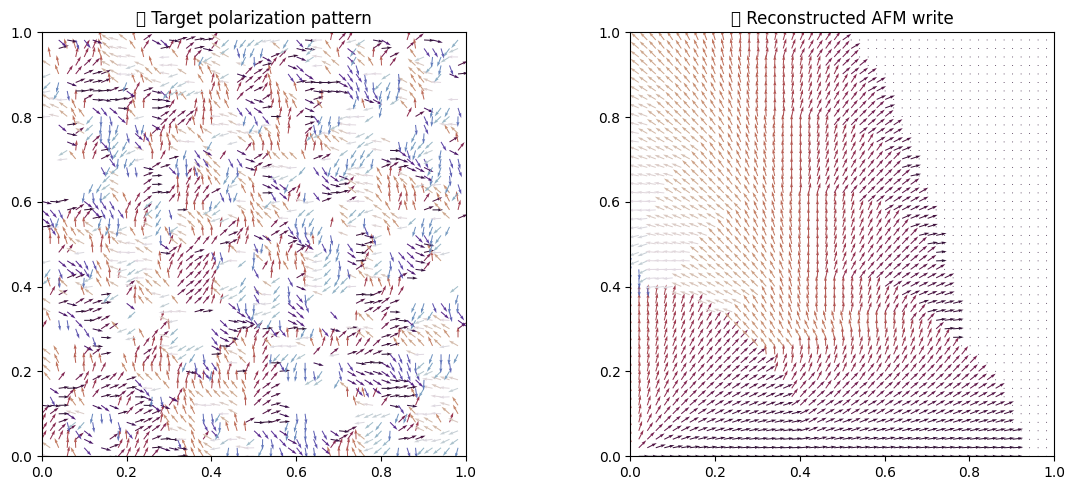

In [32]:
# evaluate_and_plot(
#     best,
#     traj,
#     sim,
#     X,
#     Y,
#     target_Px,
#     target_Py
# )




recon_Px, recon_Py = evaluate_and_plot(
    best,
    traj,
    sim,
    X,
    Y,
    target_Px,
    target_Py
)

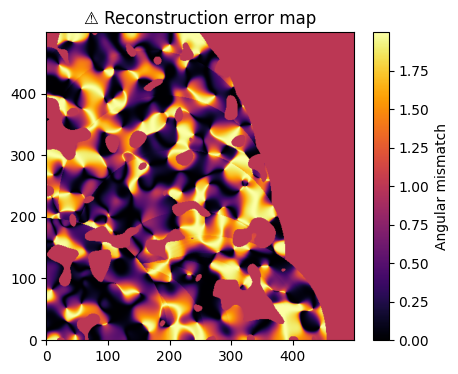

In [33]:
plot_error_map(
    X,
    Y,
    target_Px,
    target_Py,
    recon_Px,
    recon_Py
)